In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
import math
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KernelDensity

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),   # 256 -> 128
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 128 -> 64
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 32 -> 16
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), # 16 -> 8
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1), # 8 -> 16
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 32 -> 64
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),   # 64 -> 128
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),    # 128 -> 256
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

In [3]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
batch_size = 16
epochs = 100
learning_rate = 1e-3
patience = 12
print("Device:", device)

transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomRotation(3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor()
])
transform_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])

dataset_train = datasets.ImageFolder("train/", transform=transform_train)
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataset_val = datasets.ImageFolder("val/", transform=transform_eval)
good_idx_val = dataset_val.class_to_idx["good"]
val_good_indices = [i for i, label in enumerate(dataset_val.targets) if label == good_idx_val]
val_def_indices = [i for i, label in enumerate(dataset_val.targets) if label != good_idx_val]
val_good_loader = DataLoader(Subset(dataset_val, val_good_indices), batch_size=batch_size, shuffle=False)
val_def_loader = DataLoader(Subset(dataset_val, val_def_indices), batch_size=batch_size, shuffle=False)
dataset_test = datasets.ImageFolder("test/", transform=transform_eval)
good_idx_test = dataset_test.class_to_idx["good"]
test_good_indices = [i for i, label in enumerate(dataset_test.targets) if label == good_idx_test]
test_def_indices = [i for i, label in enumerate(dataset_test.targets) if label != good_idx_test]
test_good_loader = DataLoader(Subset(dataset_test, test_good_indices), batch_size=batch_size, shuffle=False)
test_def_loader = DataLoader(Subset(dataset_test, test_def_indices), batch_size=batch_size, shuffle=False)
print(f"TRAIN: {len(dataset_train)}")
print(f"VAL good: {len(val_good_indices)}, VAL defect: {len(val_def_indices)}")
print(f"TEST good: {len(test_good_indices)}, TEST defect: {len(test_def_indices)}")

Device: cuda
TRAIN: 540
VAL good: 45, VAL defect: 151
TEST good: 46, TEST defect: 153


Epoch [1/100] - train_loss: 0.1121 - val_good_loss: 0.0688
Epoch [2/100] - train_loss: 0.0553 - val_good_loss: 0.0249
Epoch [3/100] - train_loss: 0.0343 - val_good_loss: 0.0200
Epoch [4/100] - train_loss: 0.0310 - val_good_loss: 0.0172
Epoch [5/100] - train_loss: 0.0278 - val_good_loss: 0.0223
Epoch [6/100] - train_loss: 0.0273 - val_good_loss: 0.0152
Epoch [7/100] - train_loss: 0.0262 - val_good_loss: 0.0212
Epoch [8/100] - train_loss: 0.0258 - val_good_loss: 0.0169
Epoch [9/100] - train_loss: 0.0268 - val_good_loss: 0.0135
Epoch [10/100] - train_loss: 0.0231 - val_good_loss: 0.0129
Epoch [11/100] - train_loss: 0.0232 - val_good_loss: 0.0154
Epoch [12/100] - train_loss: 0.0231 - val_good_loss: 0.0130
Epoch [13/100] - train_loss: 0.0217 - val_good_loss: 0.0147
Epoch [14/100] - train_loss: 0.0228 - val_good_loss: 0.0217
Epoch [15/100] - train_loss: 0.0213 - val_good_loss: 0.0137
Epoch [16/100] - train_loss: 0.0218 - val_good_loss: 0.0109
Epoch [17/100] - train_loss: 0.0205 - val_good_lo

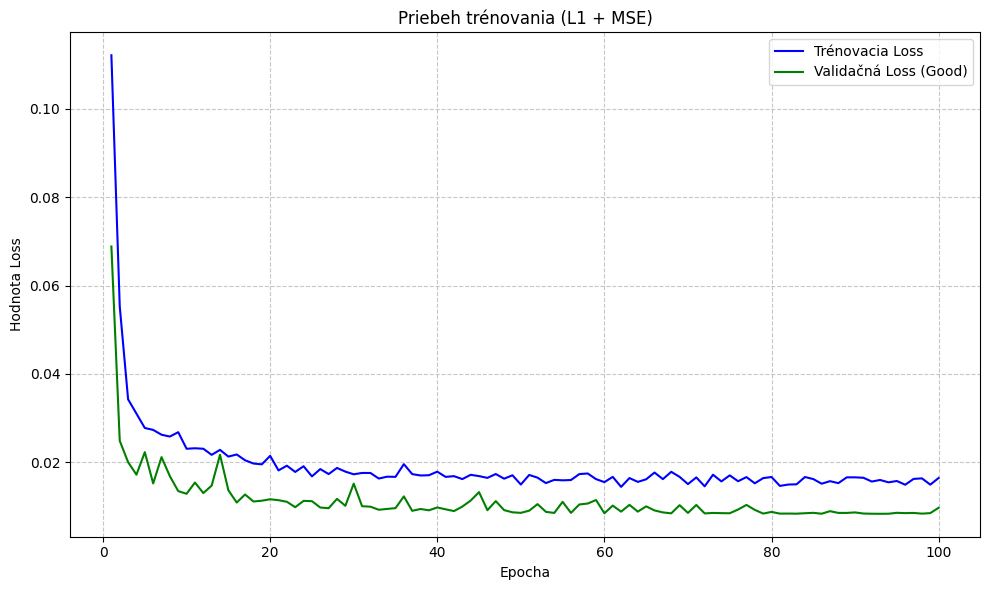

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import copy

loss_fn_l1 = nn.L1Loss()
loss_fn_mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
def reconstruction_loss(outputs, images):
    loss_l1 = loss_fn_l1(outputs, images)
    loss_mse = loss_fn_mse(outputs, images)
    return 0.5 * loss_l1 + 0.5 * loss_mse

history_train_loss = []
history_val_loss = []
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        outputs = model(images)
        loss = reconstruction_loss(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_good_loader:
            images = images.to(device)
            outputs = model(images)
            loss = reconstruction_loss(outputs, images)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_good_loader.dataset)
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    scheduler.step(val_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - train_loss: {train_loss:.4f} - val_good_loss: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_autoencoder.pth")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    if early_stop_counter >= patience:
        print(f"Early stopping na epoche {epoch+1}")
        break
model.load_state_dict(best_model_wts)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history_train_loss) + 1), history_train_loss, label='Trénovacia Loss', color='blue')
plt.plot(range(1, len(history_val_loss) + 1), history_val_loss, label='Validačná Loss (Good)', color='green')
plt.title('Priebeh trénovania (L1 + MSE)')
plt.xlabel('Epocha')
plt.ylabel('Hodnota Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

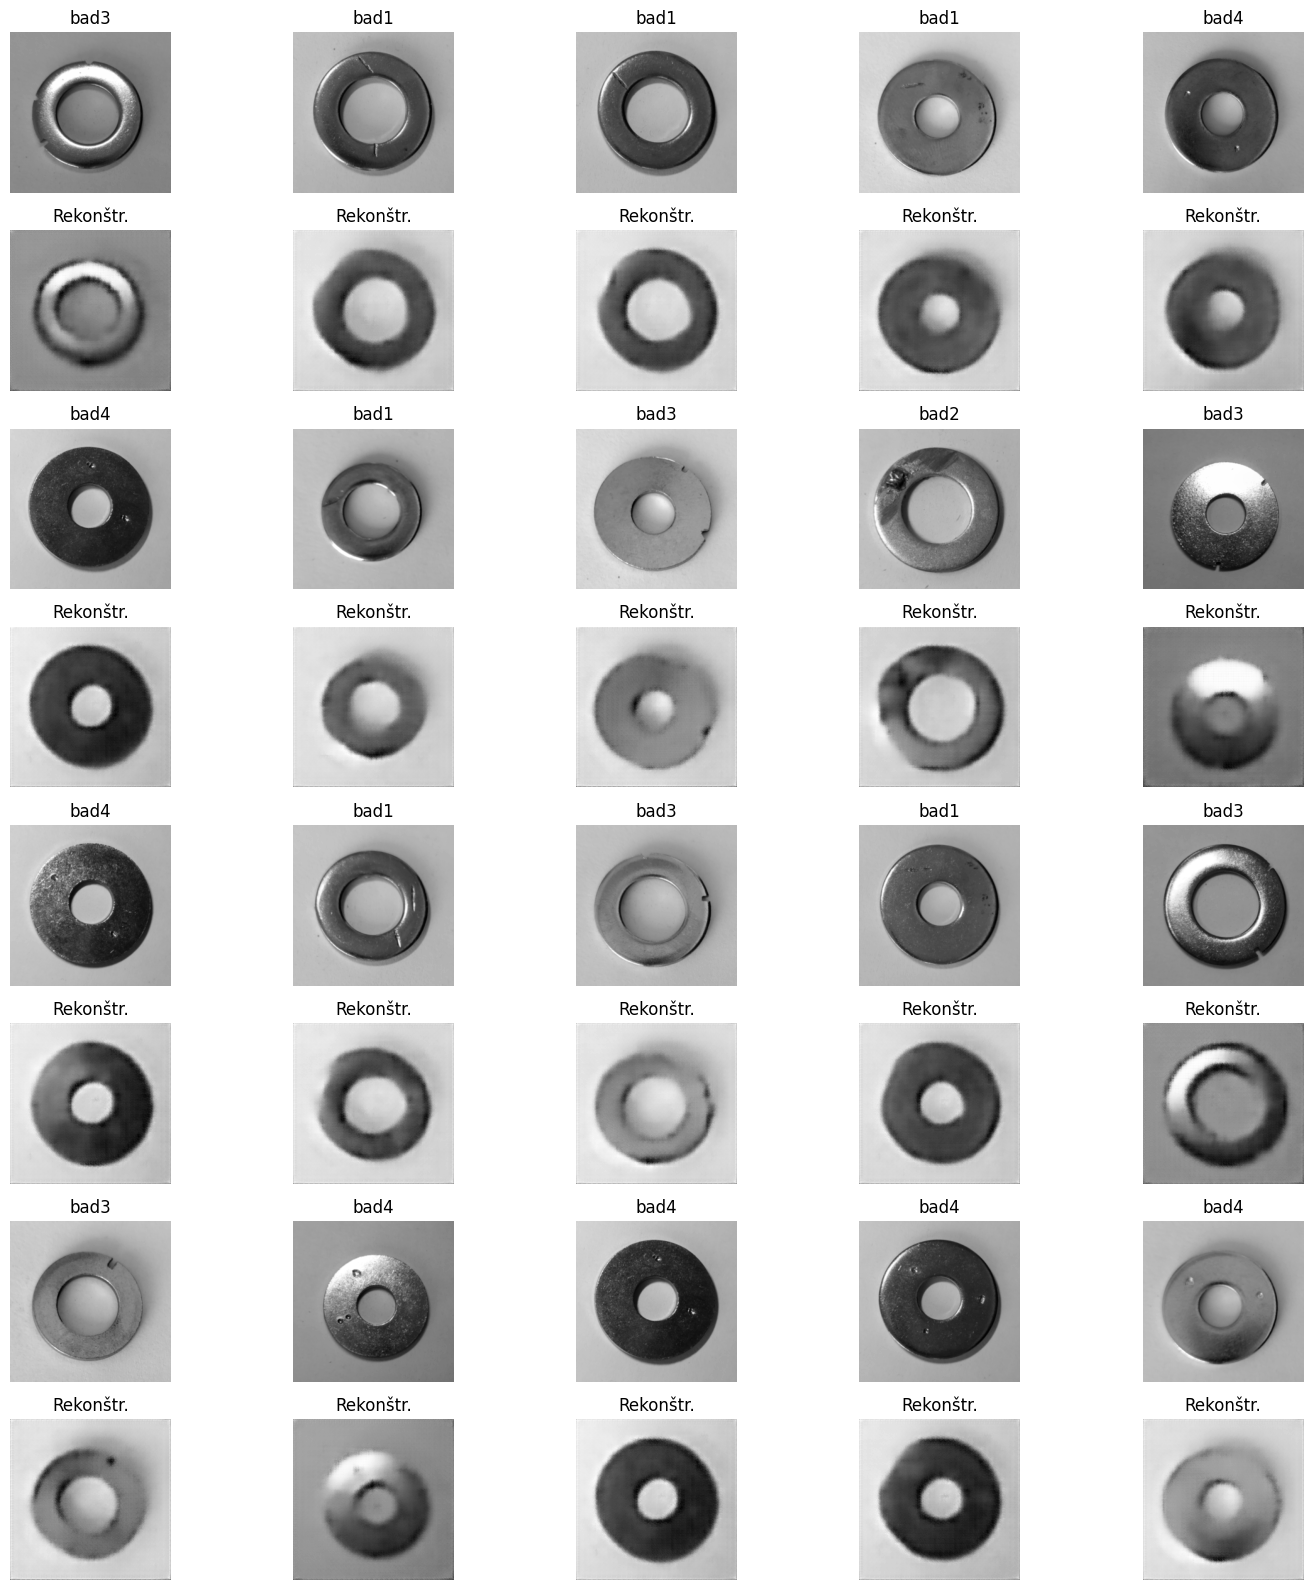

In [5]:
model.eval()
num_images = 20
num_cols = 5
subset_indices = test_def_loader.dataset.indices
num_images = min(num_images, len(subset_indices))
num_rows = math.ceil(num_images / num_cols)
random_indices = random.sample(subset_indices, num_images)
random_images = []
random_labels = []
for idx in random_indices:
    img, label = dataset_test[idx]
    random_images.append(img)
    random_labels.append(dataset_test.classes[label])
images = torch.stack(random_images).to(device)
with torch.no_grad():
    reconstructions = model(images)
fig, axes = plt.subplots(num_rows * 2, num_cols, figsize=(15, num_rows * 4))
for i in range(num_images):
    row_block = i // num_cols
    col = i % num_cols
    axes[row_block * 2, col].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[row_block * 2, col].set_title(f"{random_labels[i]}")
    axes[row_block * 2, col].axis('off')
    axes[row_block * 2 + 1, col].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[row_block * 2 + 1, col].set_title("Rekonštr.")
    axes[row_block * 2 + 1, col].axis('off')
total_slots = num_rows * num_cols
for j in range(num_images, total_slots):
    row_block = j // num_cols
    col = j % num_cols
    axes[row_block * 2, col].axis('off')
    axes[row_block * 2 + 1, col].axis('off')
plt.tight_layout()
plt.show()

THRESHOLD Z VALIDÁCIE (Alpha = 0.5)
Best threshold: 0.045409
Best validation F1: 0.879765
VAL good   - mean: 0.081628, std: 0.026893
VAL defect - mean: 0.098686, std: 0.026945
Separation gap: 0.017058


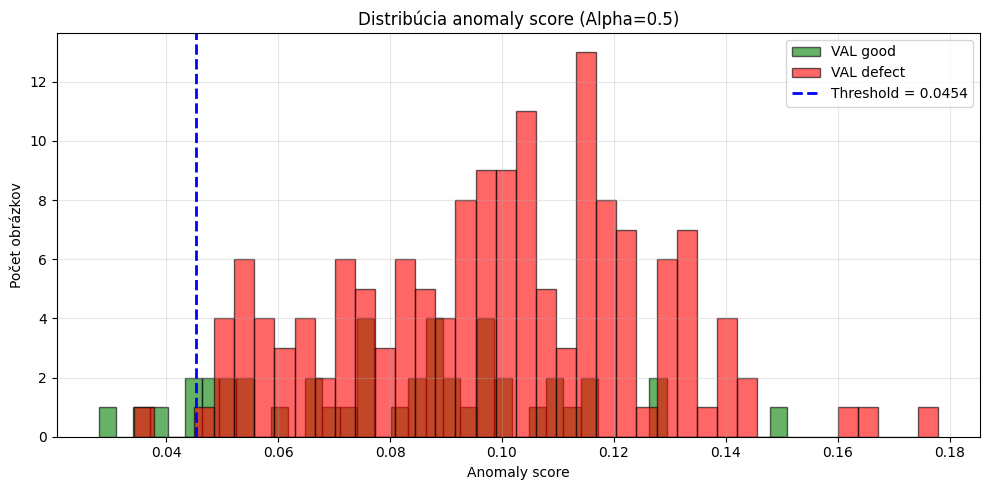

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pytorch_msssim import ssim
from sklearn.metrics import f1_score

loss_fn_l1_none = nn.L1Loss(reduction='none')

def get_anomaly_scores(loader, model, device, alpha=0.5):
    scores = []
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructions = model(images)

            l1_err = loss_fn_l1_none(reconstructions, images)
            l1_score = l1_err.mean(dim=(1, 2, 3))

            ssim_val = ssim(reconstructions, images, data_range=1.0, size_average=False)
            ssim_score = 1 - ssim_val

            score = (alpha * ssim_score) + ((1 - alpha) * l1_score)
            scores.extend(score.cpu().numpy())

    return np.array(scores)

alpha_val = 0.5

val_normal_scores = get_anomaly_scores(val_good_loader, model, device, alpha=alpha_val)
val_defect_scores = get_anomaly_scores(val_def_loader, model, device, alpha=alpha_val)

y_val_true = np.concatenate([
    np.zeros(len(val_normal_scores), dtype=int),
    np.ones(len(val_defect_scores), dtype=int)
])

y_val_scores = np.concatenate([val_normal_scores, val_defect_scores])

thresholds = np.linspace(y_val_scores.min(), y_val_scores.max(), 500)

best_thresh = None
best_f1 = -1

for thr in thresholds:
    y_val_pred = (y_val_scores > thr).astype(int)
    f1 = f1_score(y_val_true, y_val_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thr

RECON_THRESH = best_thresh

print("=" * 60)
print(f"THRESHOLD Z VALIDÁCIE (Alpha = {alpha_val})")
print("=" * 60)
print(f"Best threshold: {RECON_THRESH:.6f}")
print(f"Best validation F1: {best_f1:.6f}")
print(f"VAL good   - mean: {val_normal_scores.mean():.6f}, std: {val_normal_scores.std():.6f}")
print(f"VAL defect - mean: {val_defect_scores.mean():.6f}, std: {val_defect_scores.std():.6f}")
print(f"Separation gap: {val_defect_scores.mean() - val_normal_scores.mean():.6f}")

plt.figure(figsize=(10, 5))
plt.hist(val_normal_scores, bins=40, alpha=0.6, color='green', label='VAL good', edgecolor='black')
plt.hist(val_defect_scores, bins=40, alpha=0.6, color='red', label='VAL defect', edgecolor='black')
plt.axvline(RECON_THRESH, color='blue', linestyle='--', linewidth=2, label=f'Threshold = {RECON_THRESH:.4f}')
plt.title(f'Distribúcia anomaly score (Alpha={alpha_val})')
plt.xlabel('Anomaly score')
plt.ylabel('Počet obrázkov')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



VYHODNOTENIE NA TEST SETE
TEST good   - mean: 0.081423, std: 0.024527
TEST defect - mean: 0.098560, std: 0.029073


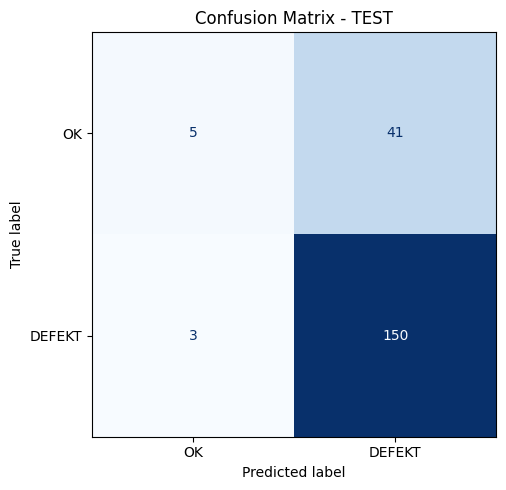

              precision    recall  f1-score   support

          OK       0.62      0.11      0.19        46
      DEFEKT       0.79      0.98      0.87       153

    accuracy                           0.78       199
   macro avg       0.71      0.54      0.53       199
weighted avg       0.75      0.78      0.71       199



In [11]:
test_normal_scores = get_anomaly_scores(test_good_loader, model, device, alpha=alpha_val)
test_defect_scores = get_anomaly_scores(test_def_loader, model, device, alpha=alpha_val)
y_true = np.concatenate([
    np.zeros(len(test_normal_scores), dtype=int),
    np.ones(len(test_defect_scores), dtype=int)
])
y_scores = np.concatenate([
    test_normal_scores,
    test_defect_scores
])
y_pred = (y_scores > RECON_THRESH).astype(int)
cm = confusion_matrix(y_true, y_pred)
print("\n" + "=" * 60)
print("VYHODNOTENIE NA TEST SETE")
print("=" * 60)
print(f"TEST good   - mean: {test_normal_scores.mean():.6f}, std: {test_normal_scores.std():.6f}")
print(f"TEST defect - mean: {test_defect_scores.mean():.6f}, std: {test_defect_scores.std():.6f}")
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['OK', 'DEFEKT'])
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
plt.title('Confusion Matrix - TEST')
plt.tight_layout()
plt.show()
print(classification_report(y_true, y_pred, target_names=['OK', 'DEFEKT'], zero_division=0))

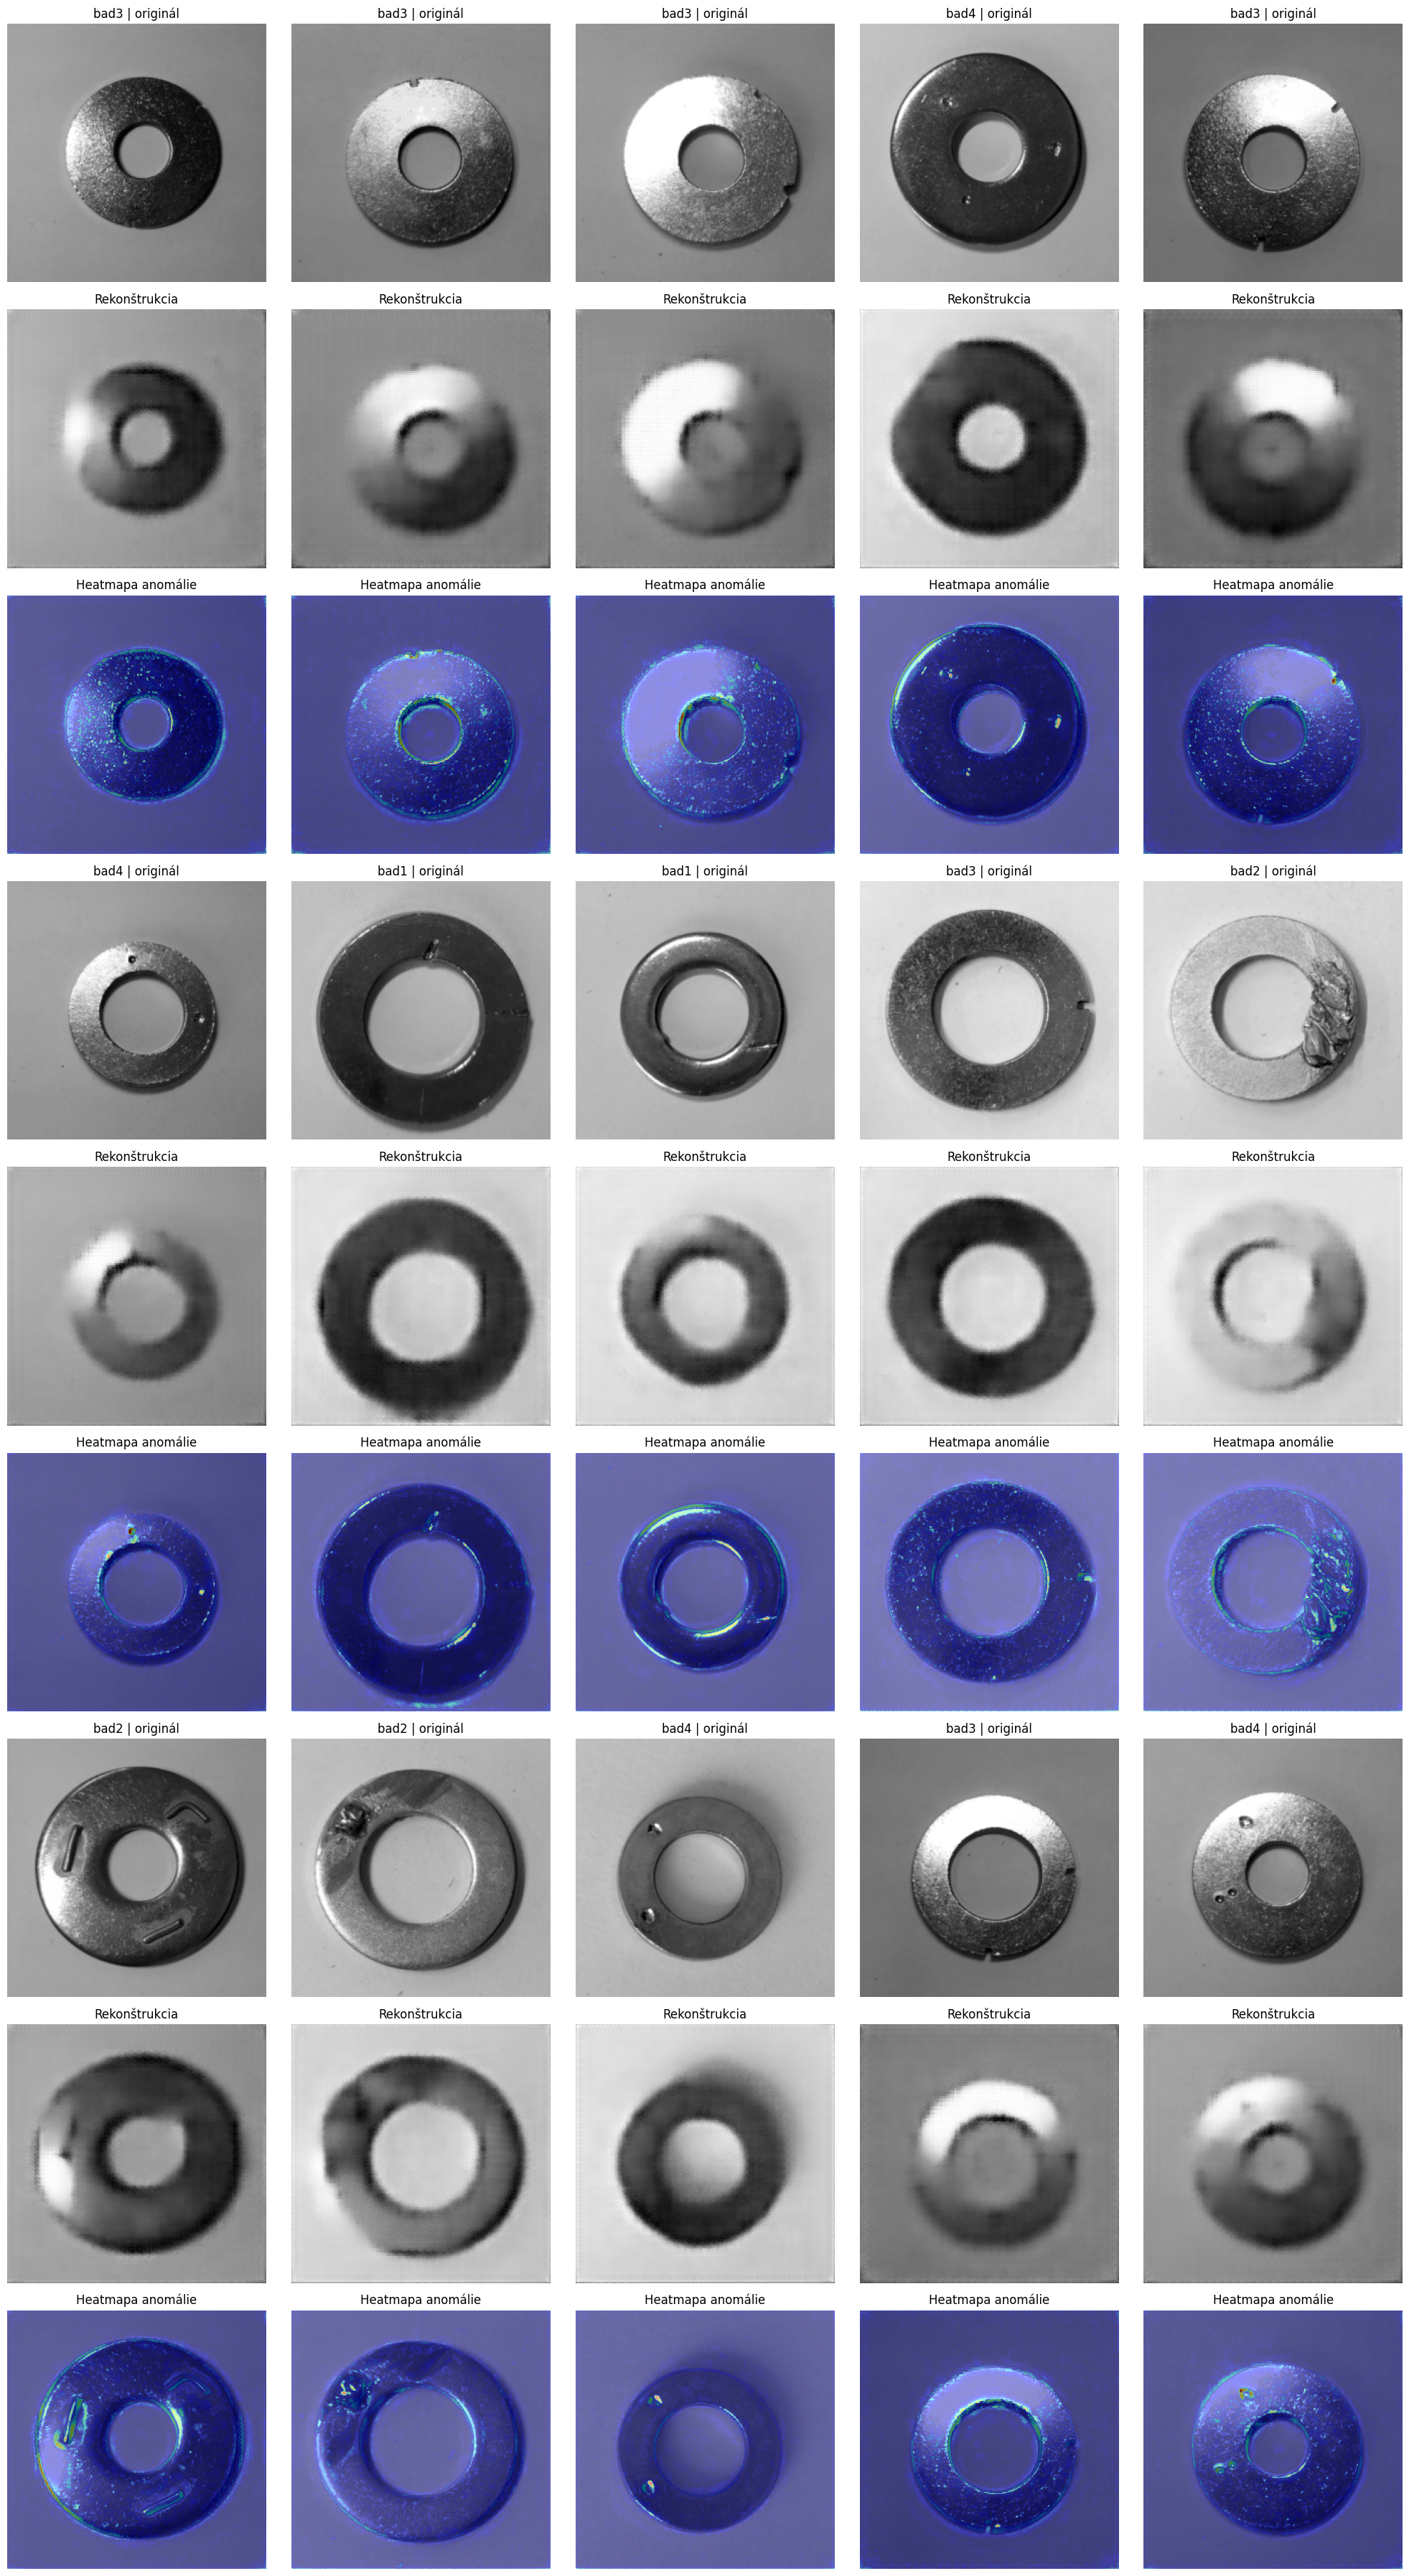

In [9]:
def show_anomaly_heatmaps(model, dataset, subset_loader, device, num_images=15, num_cols=5):
    model.eval()
    subset_indices = subset_loader.dataset.indices
    num_images = min(num_images, len(subset_indices))
    random_indices = random.sample(subset_indices, num_images)
    random_images = []
    random_labels = []
    for idx in random_indices:
        img, label = dataset[idx]
        random_images.append(img)
        random_labels.append(dataset.classes[label])
    images = torch.stack(random_images).to(device)
    with torch.no_grad():
        reconstructions = model(images)
        error_maps = torch.abs(reconstructions - images)
    num_blocks = math.ceil(num_images / num_cols)
    fig, axes = plt.subplots(num_blocks * 3, num_cols, figsize=(4 * num_cols, 4 * num_blocks * 3))
    for i in range(num_images):
        block = i // num_cols
        col = i % num_cols
        orig_row = block * 3
        rec_row = block * 3 + 1
        heat_row = block * 3 + 2
        img_np = images[i].cpu().squeeze().numpy()
        rec_np = reconstructions[i].cpu().squeeze().numpy()
        err_np = error_maps[i].cpu().squeeze().numpy()
        axes[orig_row, col].imshow(img_np, cmap='gray')
        axes[orig_row, col].set_title(f"{random_labels[i]} | originál")
        axes[orig_row, col].axis('off')
        axes[rec_row, col].imshow(rec_np, cmap='gray')
        axes[rec_row, col].set_title("Rekonštrukcia")
        axes[rec_row, col].axis('off')
        axes[heat_row, col].imshow(img_np, cmap='gray')
        axes[heat_row, col].imshow(err_np, cmap='jet', alpha=0.45)
        axes[heat_row, col].set_title("Heatmapa anomálie")
        axes[heat_row, col].axis('off')
    total_slots = num_blocks * num_cols
    for i in range(num_images, total_slots):
        block = i // num_cols
        col = i % num_cols
        axes[block * 3, col].axis('off')
        axes[block * 3 + 1, col].axis('off')
        axes[block * 3 + 2, col].axis('off')
    plt.tight_layout()
    plt.show()
show_anomaly_heatmaps(model, dataset_test, test_def_loader, device, num_images=15)